In [14]:
from pandas import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import json

In [15]:
# Define both datasets
datasets = [
    {
        'id': 0,
        'name': 'CW09',
        'pef_file': "rgb_out/cw09.out",
        'pisa_file': "/home/angelosav/experiments/pisa/cw09.out",
        'ds2i_file': "/home/angelosav/experiments/vbmw/cw09.out"
    },
    {
        'id': 1,
        'name': 'CCNews',
        'pef_file': "rgb_out/cc.out",
        'pisa_file': "/home/angelosav/experiments/pisa/ccnews.out",
        'ds2i_file': "/home/angelosav/experiments/vbmw/ccnews.out"
    }
]

## Process Both Datasets

In [16]:
def format_exp(x):
    """Distinguish between variable and static for BMWand and BMMaxScore"""
    if x['exp'] == "BMWand" or x['exp'] == "BMMaxScore":
        return x['exp'] + " - " + ("var" if 'var' in x['mdata_filename'] else "static")
    return x['exp']

def process_pef_data(pef_file):
    """Read and process PEF results from file"""
    pef_df = []
    for l in open(pef_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            pef_df.append(json.loads(a))
    
    pef_df = DataFrame(pef_df)
    pef_df.loc[:, 'exp'] = pef_df[:].apply(format_exp, axis=1)
    return pef_df

def process_pisa_data(pisa_file):
    """Read and process PISA results from file"""
    pisa_df = []
    for l in open(pisa_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            pisa_df.append(json.loads(a))
    
    pisa_df = DataFrame(pisa_df)
    
    # Rename WAND experiments
    mask = pisa_df['query'] == 'block_max_wand'
    pisa_df.loc[mask, 'query'] = [
        'block_max_wand - static' if i % 2 == 0 else 'block_max_wand - var' 
        for i, _ in enumerate(pisa_df[mask].index)
    ]
    
    # Rename MAXSCORE experiments
    mask = pisa_df['query'] == 'block_max_maxscore'
    pisa_df.loc[mask, 'query'] = [
        'block_max_maxscore - static' if i % 2 == 0 else 'block_max_maxscore - var' 
        for i, _ in enumerate(pisa_df[mask].index)
    ]
    
    return pisa_df

def process_ds2i_data(ds2i_file):
    """Read and process DS2I results from file"""
    ds2i_df = []
    for l in open(ds2i_file, "r").readlines():
        a = l.strip()
        if a.startswith("{") and a.endswith("}"):
            ds2i_df.append(json.loads(a))
    
    ds2i_df = DataFrame(ds2i_df)
    
    # Rename WAND experiments
    mask = ds2i_df['query'] == 'block_max_wand'
    ds2i_df.loc[mask, 'query'] = [
        'block_max_wand - static' if i % 2 == 0 else 'block_max_wand - var' 
        for i, _ in enumerate(ds2i_df[mask].index)
    ]
    
    return ds2i_df

# Process all datasets
dataset_results = {}

for dataset in datasets:
    dataset_name = dataset['name']
    print(f"Processing {dataset_name}...")
    
    # Process PEF data
    pef_df = process_pef_data(dataset['pef_file'])
    
    # Process PISA data
    pisa_df = process_pisa_data(dataset['pisa_file'])
    
    # Process DS2I data
    ds2i_df = process_ds2i_data(dataset['ds2i_file'])
    
    dataset_results[dataset_name] = {
        'pef_df': pef_df,
        'pisa_df': pisa_df,
        'ds2i_df': ds2i_df
    }

print("All datasets processed!")

Processing CW09...
Processing CCNews...
All datasets processed!


## Space Usage Comparison


CW09 Space Usage:
                 index_ty  space_usage_MiB
0                   EFIdx        18.608398
9                 UPISIdx        14.962217
18               OptEFIdx        13.738740
27  BlockInterpolativeIdx        13.637246
36          BlockVByteIdx        46.039463

CCNews Space Usage:
                 index_ty  space_usage_MiB
0                   EFIdx        20.101406
9                 UPISIdx        13.502227
18               OptEFIdx        12.023164
27  BlockInterpolativeIdx        12.352764
36          BlockVByteIdx        54.823652


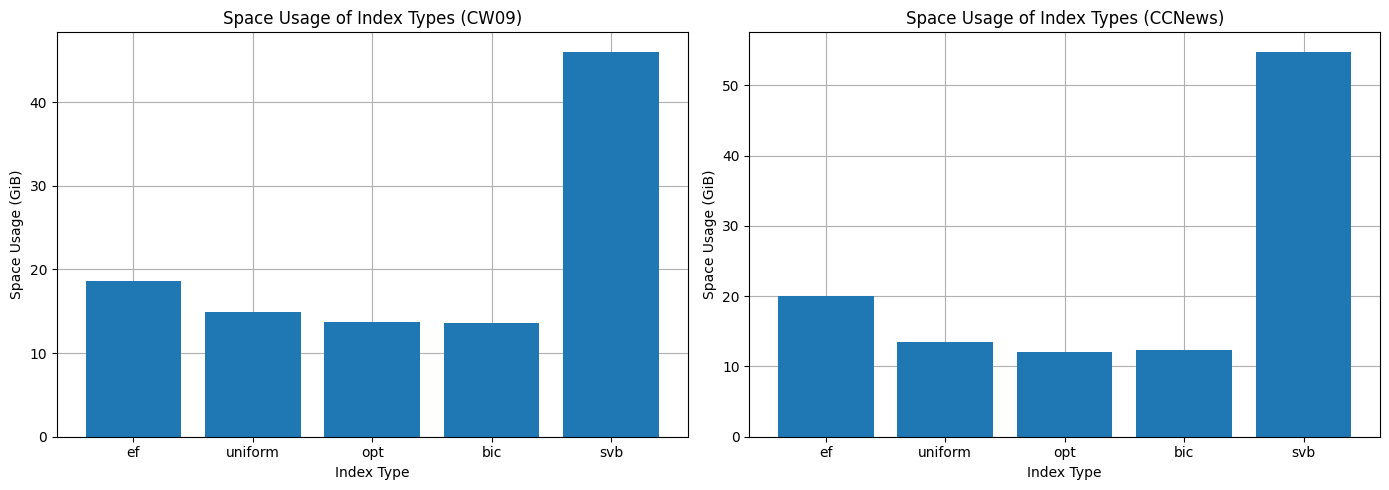

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, dataset in enumerate(datasets):
    dataset_name = dataset['name']
    pef_df = dataset_results[dataset_name]['pef_df']
    
    pef_df_space = pef_df[['index_ty', 'space_usage_MiB']].drop_duplicates()
    pef_df_space['space_usage_MiB'] = pef_df_space['space_usage_MiB'] / 1024
    
    ax = axes[idx]
    ax.bar(['ef', 'uniform', 'opt', 'bic', 'svb'], pef_df_space['space_usage_MiB'], zorder=2)
    ax.grid(zorder=3)
    ax.set_title(f'Space Usage of Index Types ({dataset_name})')
    ax.set_xlabel('Index Type')
    ax.set_ylabel('Space Usage (GiB)')
    
    print(f"\n{dataset_name} Space Usage:")
    print(pef_df_space)

plt.tight_layout()
plt.show()

In [18]:
def create_pef_times_df(pef_df):
    """Create formatted time comparison dataframe for PEF"""
    # Reshape the dataframe
    pef_df_times = pef_df.pivot(index='index_ty', columns='exp', values='avg')
    pef_df_times.columns.name = None
    
    ordered_index = ['EFIdx', 'UPISIdx', 'OptEFIdx', 'BlockInterpolativeIdx', 'BlockVByteIdx']
    ordered_columns = ['And', 'RankedAnd', 'RankedOr', 'Wand', 'MaxScore', 'BMWand - static','BMMaxScore - static', 'BMWand - var','BMMaxScore - var']
    
    pef_df_times = pef_df_times.reindex(ordered_index)
    pef_df_times = pef_df_times[ordered_columns]
    pef_df_times = pef_df_times / 1000
    
    pef_df_times = pef_df_times.rename(columns={
        'And': 'and',
        'RankedAnd': 'ranked_and',
        'RankedOr': 'ranked_or',
        'Wand': 'wand',
        'MaxScore': 'maxscore',
        'BMWand - static': 'block_max_wand - static',
        'BMMaxScore - static': 'block_max_maxscore - static',
        'BMWand - var': 'block_max_wand - var',
        'BMMaxScore - var': 'block_max_maxscore - var'
    })
    
    pef_df_times = pef_df_times.rename(index={
        'EFIdx': 'ef',
        'UPISIdx': 'uniform',
        'OptEFIdx': 'opt',
        'BlockInterpolativeIdx': 'block_interpolative',
        'BlockVByteIdx': 'block_svb/varint'
    })
    
    pef_df_times = pef_df_times.rename_axis('type')
    return pef_df_times

def create_pisa_times_df(pisa_df):
    """Create formatted time comparison dataframe for PISA"""
    pisa_df_times = pisa_df.pivot(index='type', columns='query', values='avg')
    pisa_df_times.columns.name = None
    
    pisa_df_times = pisa_df_times.rename(index={
        'pefopt': 'opt',
        'pefuniform': 'uniform',
        'block_streamvbyte': 'block_svb/varint',
    })
    
    pisa_df_times = pisa_df_times / 1000
    return pisa_df_times

def create_ds2i_times_df(ds2i_df):
    """Create formatted time comparison dataframe for DS2I"""
    ds2i_df_times = ds2i_df.pivot(index='type', columns='query', values='avg')
    ds2i_df_times.columns.name = None
    
    ds2i_df_times = ds2i_df_times.rename(index={
        'block_varint': 'block_svb/varint'
    })
    
    ds2i_df_times = ds2i_df_times / 1000
    return ds2i_df_times

# Create time dataframes for all datasets
for dataset in datasets:
    dataset_name = dataset['name']
    print(f"\n{'='*50}")
    print(f"Processing times for {dataset_name}")
    print(f"{'='*50}")
    
    pef_df_times = create_pef_times_df(dataset_results[dataset_name]['pef_df'])
    pisa_df_times = create_pisa_times_df(dataset_results[dataset_name]['pisa_df'])
    ds2i_df_times = create_ds2i_times_df(dataset_results[dataset_name]['ds2i_df'])
    
    dataset_results[dataset_name]['pef_df_times'] = pef_df_times
    dataset_results[dataset_name]['pisa_df_times'] = pisa_df_times
    dataset_results[dataset_name]['ds2i_df_times'] = ds2i_df_times
    
    print(f"\n{dataset_name} PEF Times:")
    print(pef_df_times)


Processing times for CW09

CW09 PEF Times:
                        and  ranked_and  ranked_or    wand  maxscore  \
type                                                                   
ef                    5.882       9.604    108.547  12.335    10.370   
uniform               7.513      12.166    126.553  15.427    11.039   
opt                   6.681      10.814    122.419  13.612    11.080   
block_interpolative  20.391      35.187    236.087  44.791    19.792   
block_svb/varint      5.138       7.201     83.731  13.101    11.892   

                     block_max_wand - static  block_max_maxscore - static  \
type                                                                        
ef                                     4.446                       11.348   
uniform                                4.950                       11.660   
opt                                    4.512                       12.421   
block_interpolative                   15.912                      

# Combined Results - Query Times

In [19]:
def combine_all_results(pef_df_times, pisa_df_times, ds2i_df_times):
    """Combine PEF, PISA, and DS2I results into a single dataframe"""
    pef_df_times['lib'] = 'PEF'
    ds2i_df_times['lib'] = 'DS2I'
    pisa_df_times['lib'] = 'PISA'
    
    df = pd.concat([pef_df_times, ds2i_df_times, pisa_df_times], axis=0).reset_index().set_index(['type', 'lib']).sort_index()
    
    # Reorder index
    type_order = ['ef', 'uniform', 'opt', 'block_interpolative', 'block_svb/varint']
    lib_order = ['PEF', 'PISA', 'DS2I']
    df = df.reindex(type_order, level='type')
    df = df.reindex(lib_order, level='lib')
    
    df = df.round(1)
    return df

# Create combined dataframes for both datasets
combined_results = {}

for dataset in datasets:
    dataset_name = dataset['name']
    df = combine_all_results(
        dataset_results[dataset_name]['pef_df_times'].copy(),
        dataset_results[dataset_name]['pisa_df_times'].copy(),
        dataset_results[dataset_name]['ds2i_df_times'].copy()
    )
    combined_results[dataset_name] = df
    
    print(f"\n{'='*80}")
    print(f"Combined Results for {dataset_name}")
    print(f"{'='*80}")
    print(df)


Combined Results for CW09
                           and  ranked_and  ranked_or  wand  maxscore  \
type                lib                                                 
ef                  PEF    5.9         9.6      108.5  12.3      10.4   
                    PISA   6.0         9.2      157.9  12.3       9.3   
                    DS2I   5.9         NaN      117.2  12.9      10.0   
uniform             PEF    7.5        12.2      126.6  15.4      11.0   
                    PISA   6.8        10.3      165.0  13.4      10.4   
                    DS2I   5.6         NaN      120.6  13.0       9.3   
opt                 PEF    6.7        10.8      122.4  13.6      11.1   
                    PISA   6.1         9.6      160.4  12.8      10.4   
                    DS2I   5.3         NaN      114.8  12.3       8.9   
block_interpolative PEF   20.4        35.2      236.1  44.8      19.8   
                    PISA  23.4        42.3      312.8  52.0      19.6   
                    DS2I

## Times - AND / Ranked AND / Ranked OR (Both Datasets)

In [20]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - AND / Ranked AND / Ranked OR")
    print(f"{'='*80}")
    print(df[mask][['ranked_or', 'and', 'ranked_and']])


CW09 - AND / Ranked AND / Ranked OR
                          ranked_or   and  ranked_and
type                lib                              
ef                  PEF       108.5   5.9         9.6
                    PISA      157.9   6.0         9.2
                    DS2I      117.2   5.9         NaN
uniform             PEF       126.6   7.5        12.2
                    PISA      165.0   6.8        10.3
                    DS2I      120.6   5.6         NaN
opt                 PEF       122.4   6.7        10.8
                    PISA      160.4   6.1         9.6
                    DS2I      114.8   5.3         NaN
block_interpolative PEF       236.1  20.4        35.2
                    PISA      312.8  23.4        42.3
                    DS2I      236.6  20.2         NaN
block_svb/varint    PEF        83.7   5.1         7.2
                    PISA      110.9   4.9         6.6
                    DS2I       64.2   4.5         NaN

CCNews - AND / Ranked AND / Ranked OR
      

In [21]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - LaTeX Table")
    print(f"{'='*80}")
    print(df[mask][['ranked_or', 'and', 'ranked_and']].to_latex(escape=True, float_format="%.1f"))


CW09 - LaTeX Table
\begin{tabular}{llrrr}
\toprule
 &  & ranked\_or & and & ranked\_and \\
type & lib &  &  &  \\
\midrule
\multirow[t]{3}{*}{ef} & PEF & 108.5 & 5.9 & 9.6 \\
 & PISA & 157.9 & 6.0 & 9.2 \\
 & DS2I & 117.2 & 5.9 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{uniform} & PEF & 126.6 & 7.5 & 12.2 \\
 & PISA & 165.0 & 6.8 & 10.3 \\
 & DS2I & 120.6 & 5.6 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{opt} & PEF & 122.4 & 6.7 & 10.8 \\
 & PISA & 160.4 & 6.1 & 9.6 \\
 & DS2I & 114.8 & 5.3 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{block\_interpolative} & PEF & 236.1 & 20.4 & 35.2 \\
 & PISA & 312.8 & 23.4 & 42.3 \\
 & DS2I & 236.6 & 20.2 & NaN \\
\cline{1-5}
\multirow[t]{3}{*}{block\_svb/varint} & PEF & 83.7 & 5.1 & 7.2 \\
 & PISA & 110.9 & 4.9 & 6.6 \\
 & DS2I & 64.2 & 4.5 & NaN \\
\cline{1-5}
\bottomrule
\end{tabular}


CCNews - LaTeX Table
\begin{tabular}{llrrr}
\toprule
 &  & ranked\_or & and & ranked\_and \\
type & lib &  &  &  \\
\midrule
\multirow[t]{3}{*}{ef} & PEF & 97.2 & 5.3 & 9.4 

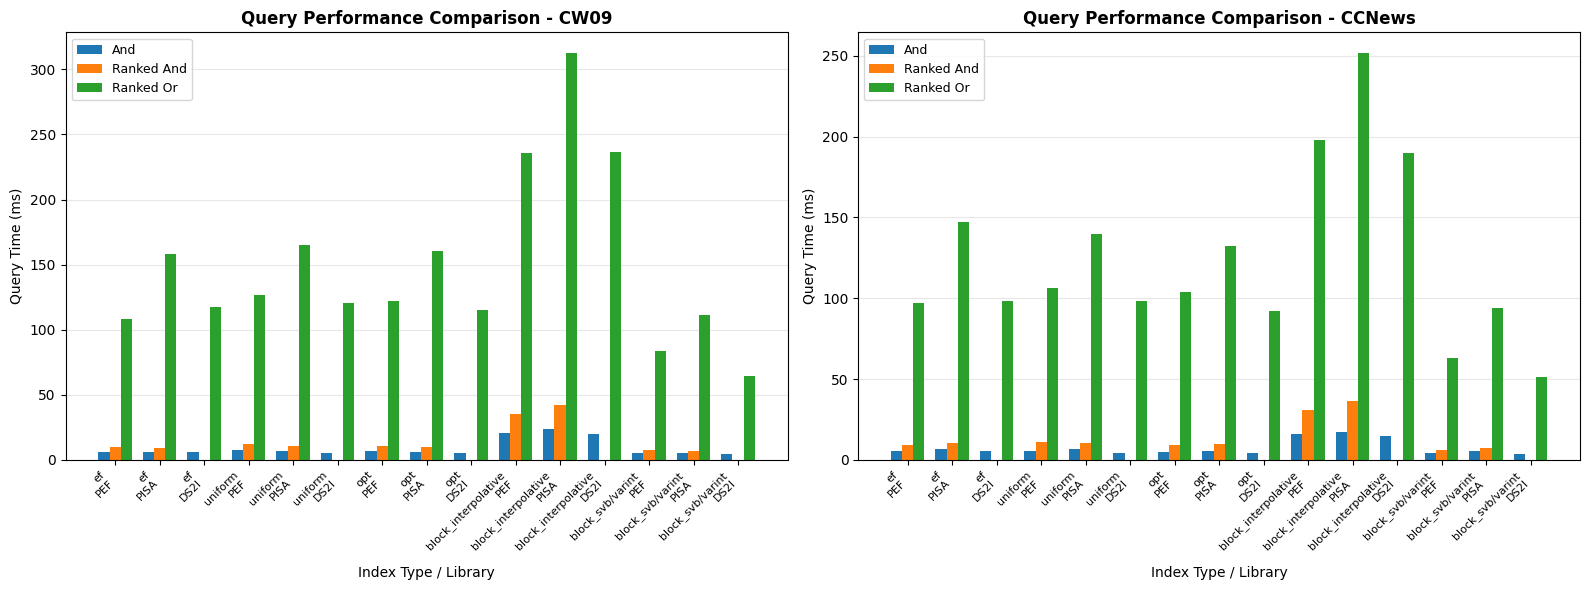

In [27]:
# Visualize AND / Ranked AND / Ranked OR times
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

query_types = ['and', 'ranked_and', 'ranked_or']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, dataset in enumerate(datasets):
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'DS2I', 'PISA'])
    data = df[mask][query_types]
    
    ax = axes[idx]
    
    # Prepare data for grouped bar chart
    index_types = data.index.get_level_values('type').unique()
    x = range(len(data))
    width = 0.25
    
    # Plot bars for each query type
    for i, query_type in enumerate(query_types):
        positions = [j + i * width for j in range(len(data))]
        ax.bar(positions, data[query_type].values, width, 
               label=query_type.replace('_', ' ').title(), 
               color=colors[i], zorder=2)
    
    # Customize the plot
    ax.set_xlabel('Index Type / Library', fontsize=10)
    ax.set_ylabel('Query Time (ms)', fontsize=10)
    ax.set_title(f'Query Performance Comparison - {dataset_name}', fontsize=12, fontweight='bold')
    ax.set_xticks([j + width for j in range(len(data))])
    
    # Create labels with both type and library
    labels = [f"{t}\n{l}" for t, l in data.index]
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', zorder=1, alpha=0.3)

plt.tight_layout()
plt.show()

## Times - Wand / MaxScore (Both Datasets)

In [22]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'PISA', 'DS2I'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Wand / MaxScore")
    print(f"{'='*80}")
    print(df[mask][['wand', 'maxscore']])


CW09 - Wand / MaxScore
                          wand  maxscore
type                lib                 
ef                  PEF   12.3      10.4
                    PISA  12.3       9.3
                    DS2I  12.9      10.0
uniform             PEF   15.4      11.0
                    PISA  13.4      10.4
                    DS2I  13.0       9.3
opt                 PEF   13.6      11.1
                    PISA  12.8      10.4
                    DS2I  12.3       8.9
block_interpolative PEF   44.8      19.8
                    PISA  52.0      19.6
                    DS2I  46.6      17.2
block_svb/varint    PEF   13.1      11.9
                    PISA   9.5       5.9
                    DS2I   9.1       5.2

CCNews - Wand / MaxScore
                          wand  maxscore
type                lib                 
ef                  PEF   13.3      11.5
                    PISA  14.3      11.3
                    DS2I  13.8      10.9
uniform             PEF   15.5      11.6
       

## Times - Block Versions (Both Datasets)

In [23]:
for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    mask = df.index.get_level_values('lib').isin(['PEF', 'PISA', 'DS2I'])
    
    print(f"\n{'='*80}")
    print(f"{dataset_name} - Block Max Wand / MaxScore")
    print(f"{'='*80}")
    print(df[mask][['block_max_wand - static', 'block_max_maxscore - static', 'block_max_wand - var', 'block_max_maxscore - var']])


CW09 - Block Max Wand / MaxScore
                          block_max_wand - static  \
type                lib                             
ef                  PEF                       4.4   
                    PISA                      5.4   
                    DS2I                      5.6   
uniform             PEF                       5.0   
                    PISA                      5.6   
                    DS2I                      5.3   
opt                 PEF                       4.5   
                    PISA                      5.5   
                    DS2I                      5.3   
block_interpolative PEF                      15.9   
                    PISA                     19.6   
                    DS2I                     17.4   
block_svb/varint    PEF                       4.9   
                    PISA                      5.0   
                    DS2I                      5.1   

                          block_max_maxscore - static  block_max

# Cross-Dataset Comparison

In [24]:
# Compare PEF performance across datasets
print("PEF Performance Comparison (CW09 vs CCNews)")
print("="*80)

cw09_pef = combined_results['CW09'].loc[combined_results['CW09'].index.get_level_values('lib') == 'PEF']
ccnews_pef = combined_results['CCNews'].loc[combined_results['CCNews'].index.get_level_values('lib') == 'PEF']

# Select common columns for comparison
common_cols = ['and', 'ranked_and', 'ranked_or', 'wand', 'maxscore']
comparison = pd.DataFrame({
    'CW09': cw09_pef[common_cols].mean(),
    'CCNews': ccnews_pef[common_cols].mean()
})
comparison['Ratio (CCNews/CW09)'] = comparison['CCNews'] / comparison['CW09']
print(comparison.round(2))

PEF Performance Comparison (CW09 vs CCNews)
              CW09  CCNews  Ratio (CCNews/CW09)
and           9.12    7.32                 0.80
ranked_and   15.00   13.40                 0.89
ranked_or   135.46  113.62                 0.84
wand         19.84   19.50                 0.98
maxscore     12.84   12.68                 0.99


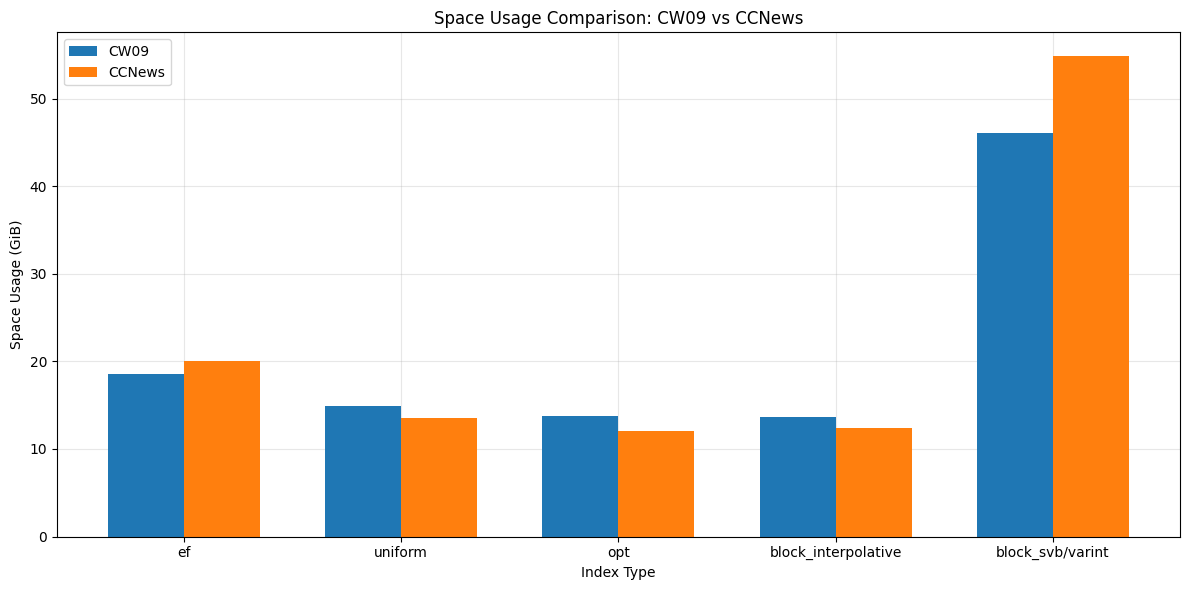

In [25]:
# Visualize space usage comparison across datasets
index_types = ['ef', 'uniform', 'opt', 'block_interpolative', 'block_svb/varint']
x = range(len(index_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

cw09_space = []
ccnews_space = []

for idx_type in index_types:
    cw09_pef = dataset_results['CW09']['pef_df']
    ccnews_pef = dataset_results['CCNews']['pef_df']
    
    # Map index type names
    type_map = {
        'ef': 'EFIdx',
        'uniform': 'UPISIdx', 
        'opt': 'OptEFIdx',
        'block_interpolative': 'BlockInterpolativeIdx',
        'block_svb/varint': 'BlockVByteIdx'
    }
    
    cw09_val = cw09_pef[cw09_pef['index_ty'] == type_map[idx_type]]['space_usage_MiB'].iloc[0] / 1024 if len(cw09_pef[cw09_pef['index_ty'] == type_map[idx_type]]) > 0 else 0
    ccnews_val = ccnews_pef[ccnews_pef['index_ty'] == type_map[idx_type]]['space_usage_MiB'].iloc[0] / 1024 if len(ccnews_pef[ccnews_pef['index_ty'] == type_map[idx_type]]) > 0 else 0
    
    cw09_space.append(cw09_val)
    ccnews_space.append(ccnews_val)

ax.bar([i - width/2 for i in x], cw09_space, width, label='CW09', zorder=2)
ax.bar([i + width/2 for i in x], ccnews_space, width, label='CCNews', zorder=2)

ax.set_xlabel('Index Type')
ax.set_ylabel('Space Usage (GiB)')
ax.set_title('Space Usage Comparison: CW09 vs CCNews')
ax.set_xticks(x)
ax.set_xticklabels(index_types)
ax.legend()
ax.grid(zorder=1, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Summary statistics for both datasets
print("\nSummary Statistics")
print("="*80)

for dataset in datasets:
    dataset_name = dataset['name']
    df = combined_results[dataset_name]
    
    print(f"\n{dataset_name}:")
    print(f"  Min query time: {df.min().min():.1f} ms")
    print(f"  Max query time: {df.max().max():.1f} ms")
    print(f"  Avg query time: {df.mean().mean():.1f} ms")


Summary Statistics

CW09:
  Min query time: 3.6 ms
  Max query time: 312.8 ms
  Avg query time: 25.5 ms

CCNews:
  Min query time: 3.0 ms
  Max query time: 251.9 ms
  Avg query time: 22.8 ms
